Employee Salary Prediction using Regression Models

In [1]:
#we imports all the required libraries first
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.metrics import (r2_score,mean_squared_error,mean_absolute_error,
confusion_matrix,precision_score,recall_score,f1_score,classification_report)

df=pd.read_csv("employee_salary.csv")
df

,age,experience,education,job_level,department,job_role,performance_rating,projects_completed,certifications,weekly_hours,...,team_size,leadership_score,skill_match,years_in_role,promotion_count,employment_type,location_type,company_size,job_satisfaction,salary
0,24,7,Masters,Junior,Finance,Manager,1,2,3,56,...,3,7.912020,7.832917,3,1,Full-time,Urban,Medium,4,57545.519834
1,53,2,Bachelors,Junior,IT,Clerk,4,18,3,50,...,11,4.362620,6.004963,6,0,Full-time,Rural,Medium,4,51024.575364
2,43,14,Masters,Mid,IT,Engineer,1,19,1,44,...,2,8.641647,8.726149,2,3,Part-time,Semi-Urban,Large,2,91913.026252
3,32,3,Bachelors,Junior,Finance,Engineer,5,4,2,51,...,1,6.099317,5.102624,0,2,Full-time,Urban,Small,1,56080.465957
4,33,19,Masters,Senior,Finance,Engineer,5,7,9,31,...,13,4.301078,7.288423,5,3,Contract,Semi-Urban,Medium,3,99002.186129
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,32,27,PhD,Senior,Sales,Analyst,1,8,4,55,...,13,5.013422,4.636595,8,0,Part-time,Rural,Medium,1,110410.336600
1496,50,3,Masters,Junior,Finance,Analyst,2,19,8,30,...,6,7.982278,8.644854,5,4,Full-time,Urban,Large,1,62997.102123
1497,47,22,Masters,Junior,Finance,Manager,5,14,3,45,...,7,1.252433,7.914028,4,0,Part-time,Semi-Urban,Small,4,106553.266077
1498,52,7,Masters,Senior,Sales,Analyst,1,14,6,42,...,3,3.623887,2.663091,6,0,Full-time,Urban,Medium,1,44807.596340


In [2]:
#now we check the simple structre and statistics of dataset.
print(df.head())
print(df.info())
print(df.describe())
print(df.shape)
print(df.ndim)

   age  experience  education job_level department  job_role  \
0   24           7    Masters    Junior    Finance   Manager   
1   53           2  Bachelors    Junior         IT     Clerk   
2   43          14    Masters       Mid         IT  Engineer   
3   32           3  Bachelors    Junior    Finance  Engineer   
4   33          19    Masters    Senior    Finance  Engineer   

   performance_rating  projects_completed  certifications  weekly_hours  ...  \
0                   1                   2               3            56  ...   
1                   4                  18               3            50  ...   
2                   1                  19               1            44  ...   
3                   5                   4               2            51  ...   
4                   5                   7               9            31  ...   

   team_size  leadership_score  skill_match  years_in_role  promotion_count  \
0          3          7.912020     7.832917            

In [3]:
#then we remove duplicates and also handling missing values
a = df.drop_duplicates()
print(a)
print(df.isnull().sum())
d = df.dropna()
print(d)


     age  experience  education job_level department  job_role  \
0     24           7    Masters    Junior    Finance   Manager   
1     53           2  Bachelors    Junior         IT     Clerk   
2     43          14    Masters       Mid         IT  Engineer   
3     32           3  Bachelors    Junior    Finance  Engineer   
4     33          19    Masters    Senior    Finance  Engineer   
..   ...         ...        ...       ...        ...       ...   
295   50          17    Masters    Senior         IT   Analyst   
296   27           0        PhD       Mid      Sales     Clerk   
297   24          17    Masters    Junior         HR     Clerk   
298   36           4    Masters    Junior    Finance  Engineer   
299   34          12        PhD    Senior         HR   Analyst   

     performance_rating  projects_completed  certifications  weekly_hours  \
0                     1                   2               3            56   
1                     4                  18          

In [4]:
#outlier detection and removal
Q1 = df['salary'].quantile(0.25)
Q3 = df['salary'].quantile(0.75)
IQR = Q3 - Q1
df = df[(df['salary']>=Q1-1.5*IQR)&(df['salary']<=Q3+1.5*IQR)]
df
print("after removing outliers shape",df.shape)

after removing outliers shape (1500, 21)


In [5]:
#filling numerical columns with mean and categorical columns with mode
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])
df

,age,experience,education,job_level,department,job_role,performance_rating,projects_completed,certifications,weekly_hours,...,team_size,leadership_score,skill_match,years_in_role,promotion_count,employment_type,location_type,company_size,job_satisfaction,salary
0,24,7,Masters,Junior,Finance,Manager,1,2,3,56,...,3,7.912020,7.832917,3,1,Full-time,Urban,Medium,4,57545.519834
1,53,2,Bachelors,Junior,IT,Clerk,4,18,3,50,...,11,4.362620,6.004963,6,0,Full-time,Rural,Medium,4,51024.575364
2,43,14,Masters,Mid,IT,Engineer,1,19,1,44,...,2,8.641647,8.726149,2,3,Part-time,Semi-Urban,Large,2,91913.026252
3,32,3,Bachelors,Junior,Finance,Engineer,5,4,2,51,...,1,6.099317,5.102624,0,2,Full-time,Urban,Small,1,56080.465957
4,33,19,Masters,Senior,Finance,Engineer,5,7,9,31,...,13,4.301078,7.288423,5,3,Contract,Semi-Urban,Medium,3,99002.186129
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,32,27,PhD,Senior,Sales,Analyst,1,8,4,55,...,13,5.013422,4.636595,8,0,Part-time,Rural,Medium,1,110410.336600
1496,50,3,Masters,Junior,Finance,Analyst,2,19,8,30,...,6,7.982278,8.644854,5,4,Full-time,Urban,Large,1,62997.102123
1497,47,22,Masters,Junior,Finance,Manager,5,14,3,45,...,7,1.252433,7.914028,4,0,Part-time,Semi-Urban,Small,4,106553.266077
1498,52,7,Masters,Senior,Sales,Analyst,1,14,6,42,...,3,3.623887,2.663091,6,0,Full-time,Urban,Medium,1,44807.596340


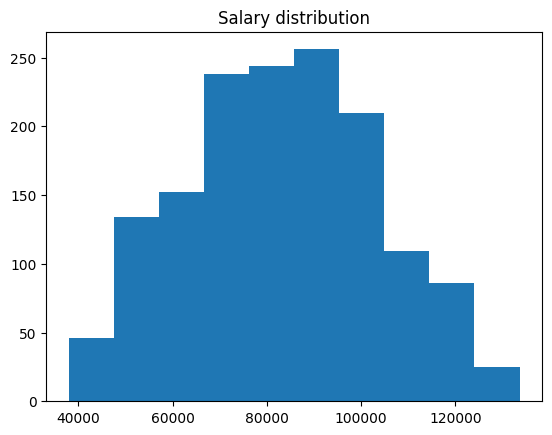

In [6]:
#data visualization
#Histogram
plt.hist(df['salary'])
plt.title("Salary distribution")
plt.show()

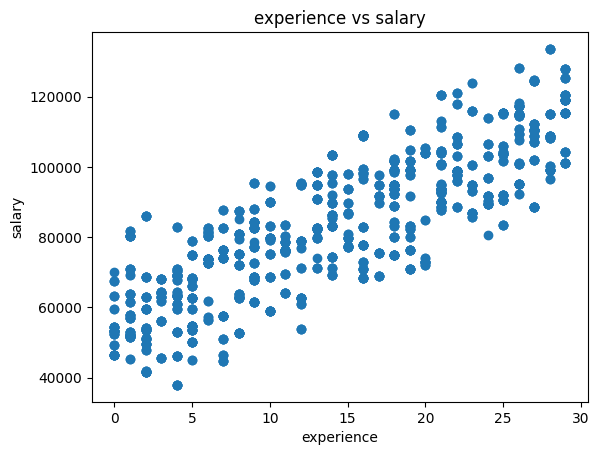

In [7]:
#Scatter plot
plt.scatter(x=df['experience'],y=df['salary'])
plt.xlabel("experience")
plt.ylabel("salary")
plt.title("experience vs salary")
plt.show()

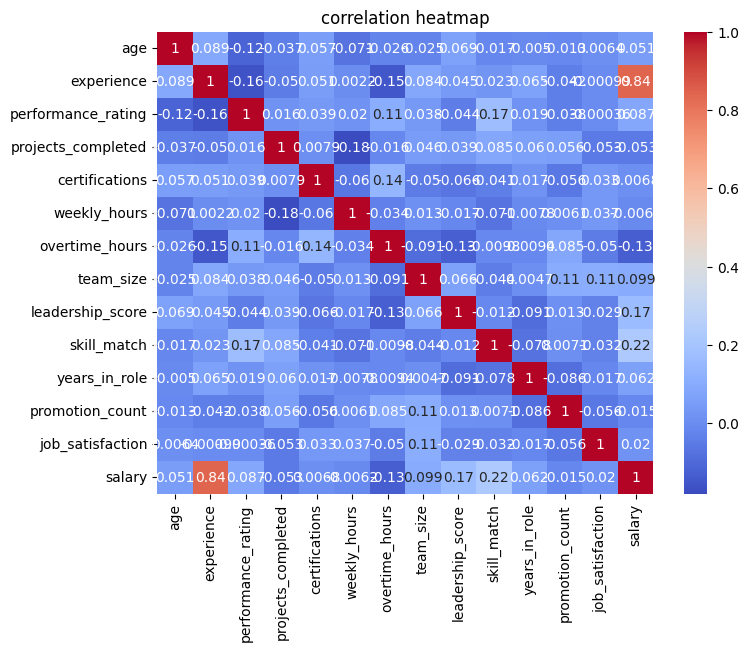

In [8]:
#heatmap
corr=df.corr(numeric_only=True)
plt.figure(figsize=(8,6))
sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.title("correlation heatmap")
plt.show()

In [9]:
#encoding(categorical data to numerical data)

df = pd.get_dummies(df, drop_first=True)

print("Data After Encoding:")
print(df.head())
print("Final Dataset Shape:", df.shape)

Data After Encoding:
   age  experience  performance_rating  projects_completed  certifications  \
0   24           7                   1                   2               3   
1   53           2                   4                  18               3   
2   43          14                   1                  19               1   
3   32           3                   5                   4               2   
4   33          19                   5                   7               9   

   weekly_hours  overtime_hours  team_size  leadership_score  skill_match  \
0            56               7          3          7.912020     7.832917   
1            50              19         11          4.362620     6.004963   
2            44              18          2          8.641647     8.726149   
3            51               7          1          6.099317     5.102624   
4            31              19         13          4.301078     7.288423   

   ...  department_Sales  job_role_Clerk  job_r

In [10]:
print(df.columns)

Index(['age', 'experience', 'performance_rating', 'projects_completed',
       'certifications', 'weekly_hours', 'overtime_hours', 'team_size',
       'leadership_score', 'skill_match', 'years_in_role', 'promotion_count',
       'job_satisfaction', 'salary', 'education_Masters', 'education_PhD',
       'job_level_Mid', 'job_level_Senior', 'department_HR', 'department_IT',
       'department_Sales', 'job_role_Clerk', 'job_role_Engineer',
       'job_role_Manager', 'employment_type_Full-time',
       'employment_type_Part-time', 'location_type_Semi-Urban',
       'location_type_Urban', 'company_size_Medium', 'company_size_Small'],
      dtype='object')


In [11]:
#feature scaling 
X = df.drop("salary", axis=1)
y = df["salary"]
print(X)
print(y)

      age  experience  performance_rating  projects_completed  certifications  \
0      24           7                   1                   2               3   
1      53           2                   4                  18               3   
2      43          14                   1                  19               1   
3      32           3                   5                   4               2   
4      33          19                   5                   7               9   
...   ...         ...                 ...                 ...             ...   
1495   32          27                   1                   8               4   
1496   50           3                   2                  19               8   
1497   47          22                   5                  14               3   
1498   52           7                   1                  14               6   
1499   48          15                   4                  14               4   

      weekly_hours  overtim

In [12]:
#Normalization and Min-Max scaler
scaler_std = StandardScaler()
X_std = scaler_std.fit_transform(X)
print(X_std.mean(axis=0))
scaler_mm = MinMaxScaler()
X_mm = scaler_mm.fit_transform(X)
print(X_mm)

[ 1.49213975e-16  4.08562073e-17  0.00000000e+00  8.64493662e-17
 -4.50010399e-17 -2.68822002e-16  9.94759830e-17  9.71075072e-17
  5.21064673e-17 -2.08129810e-16 -6.15803704e-17  1.08949886e-16
  1.06581410e-16  9.47390314e-17  1.65793305e-17  6.86857978e-17
 -5.68434189e-17  3.55271368e-17  0.00000000e+00  2.96059473e-17
 -8.76336041e-17 -8.28966525e-18  2.96059473e-17  5.92118946e-18
  4.14483263e-17 -3.01980663e-17  4.73695157e-17 -8.17124146e-17
  1.18423789e-17]
[[0.07894737 0.24137931 0.         ... 1.         1.         0.        ]
 [0.84210526 0.06896552 0.75       ... 0.         1.         0.        ]
 [0.57894737 0.48275862 0.         ... 0.         0.         0.        ]
 ...
 [0.68421053 0.75862069 1.         ... 0.         0.         1.        ]
 [0.81578947 0.24137931 0.         ... 1.         1.         0.        ]
 [0.71052632 0.51724138 0.75       ... 1.         0.         1.        ]]


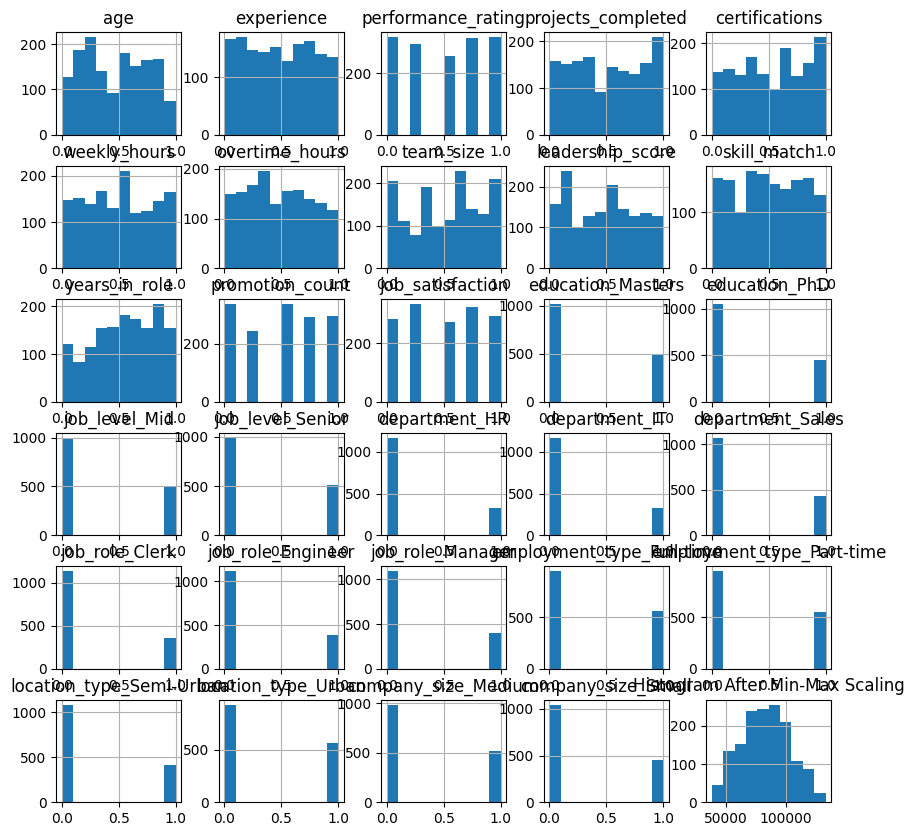

In [13]:
#visualization after Normalization and Min-Max scaler
scaled_df = pd.DataFrame(X_mm, columns=X.columns)
scaled_df['salary'] = y
#histogram
scaled_df.hist(figsize=(10,10))
plt.title("Histogram After Min-Max Scaling")
plt.show()

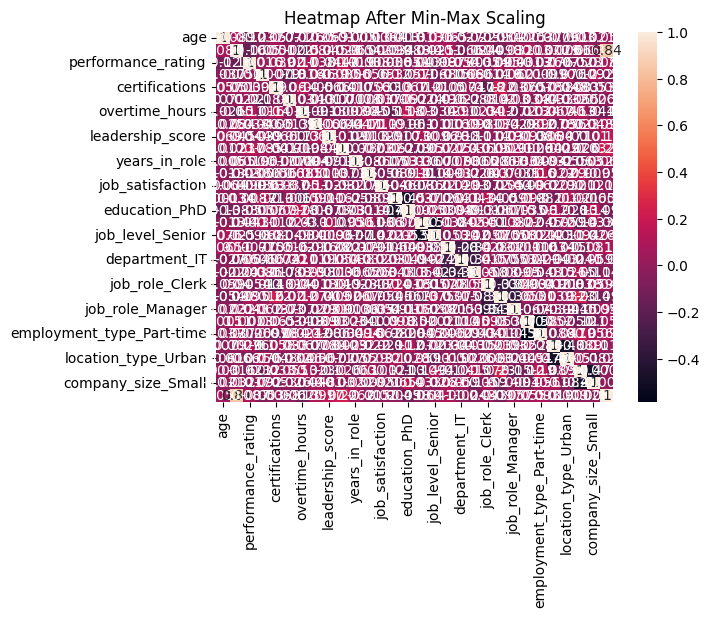

In [14]:
sns.heatmap(scaled_df.corr(), annot=True)
plt.title("Heatmap After Min-Max Scaling")
plt.show()

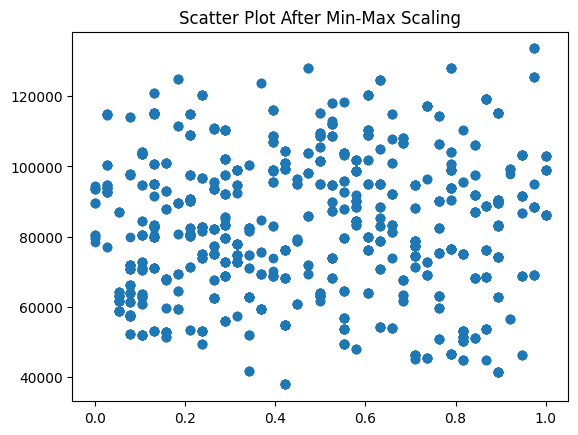

In [15]:
plt.scatter(scaled_df.iloc[:,0], scaled_df['salary'])
plt.title("Scatter Plot After Min-Max Scaling")
plt.show()

In [16]:
#train test split
X_train, X_test, y_train, y_test = train_test_split(X_mm, y, test_size=0.2)


In [17]:
#forward selection
model = LinearRegression()
sfs = SequentialFeatureSelector(model, n_features_to_select=10, direction="forward")

X_train_sfs = sfs.fit_transform(X_train, y_train)
X_test_sfs = sfs.transform(X_test)
print(X_test_sfs)

[[0.         1.         0.98327413 ... 0.         0.         1.        ]
 [0.86206897 0.75       0.47716859 ... 0.         0.         1.        ]
 [0.96551724 0.5        0.90179741 ... 0.         0.         1.        ]
 ...
 [0.55172414 1.         0.35948121 ... 0.         1.         0.        ]
 [0.75862069 0.         0.19003929 ... 0.         1.         0.        ]
 [0.13793103 0.75       0.9057793  ... 0.         0.         0.        ]]


In [18]:
#training models
#linear regression
lr = LinearRegression()
lr.fit(X_train_sfs, y_train)
pred_lr = lr.predict(X_test_sfs)
print(pred_lr)

[ 62676.877504   101873.79767705 120664.82530505  91900.08196169
  82700.69904394  96178.5377748   72874.4511344   46341.57629074
  70802.9329962   82873.2659155  112950.55773616 109109.72447658
  63292.16895351  72096.91005224  75845.2064597  120664.82530505
  93709.59396496  87038.93190435  67306.52055129  83818.53392724
  95008.16345646  75436.07236671  58378.1836287   45580.4379919
 101019.51835776  80962.41887959  85192.40451695  67132.96546009
  72592.24832399  63094.50657913  96669.91121778  94126.77701328
  82645.36124012  95662.76767626  92465.93207696  88566.73577883
  79524.3961507   52132.67882372  53546.34830054 110987.62584334
 101019.51835776  95834.00958288  93425.44980455 112215.27578257
  63807.71157987  96722.20310173  98434.67670945  71820.91978772
  63292.16895351 101873.79767705 112408.03830704  96178.5377748
  97342.10885965 109672.33177681 110782.20892699  93425.44980455
  81803.1757748   93425.44980455 105425.86356666  68368.02528713
  92170.37212819  99279.733

In [19]:
#ridge regression
ridge = Ridge()
ridge.fit(X_train_sfs, y_train)
pred_ridge = ridge.predict(X_test_sfs)
print(pred_ridge)

[ 62854.00602832 101674.13276255 120318.38000902  91805.83850195
  82706.86869263  96097.53230482  72937.82944452  46707.79076397
  70957.61345831  82891.76347577 112665.10192968 108891.36246089
  63491.72850734  72246.58529494  75888.43975863 120318.38000902
  93607.94749301  87028.75931426  67477.8372559   83826.38412861
  94916.97319132  75533.83925248  58633.75571832  45893.94460396
 100818.24259396  80971.84273545  85192.69063548  67283.38467955
  72692.23664724  63268.12832222  96501.30789338  94061.99370387
  82643.091717    95524.39598572  92387.3020537   88470.72387537
  79556.36507054  52424.54916877  53838.93246706 110713.55066563
 100818.24259396  95724.72573492  93317.30432645 111958.67641764
  64016.65030141  96593.93239331  98317.43096383  71865.32201208
  63491.72850734 101674.13276255 112154.32866273  96097.53230482
  97184.9644972  109380.26786351 110491.75940735  93317.30432645
  81776.30173652  93317.30432645 105234.03656473  68486.97456514
  92109.91612661  99143.8

In [20]:
#lasso regression
lasso = Lasso()
lasso.fit(X_train_sfs, y_train)
pred_lasso = lasso.predict(X_test_sfs)
print(pred_lasso)

[ 62675.03202592 101872.91054826 120646.80192167  91895.39554238
  82711.21160447  96160.64907414  72876.30907662  46355.60546743
  70808.36595636  82884.44462199 112942.78015237 109108.5375522
  63301.63233724  72086.77780968  75850.54149384 120646.80192167
  93700.72304596  87033.61013098  67312.45646196  83812.66958798
  94985.00049563  75436.24678297  58382.79733882  45607.55619749
 101023.25596663  80955.39762383  85183.0115584   67135.74210549
  72604.41914799  63091.59259901  96663.26377907  94124.92572929
  82643.22573184  95654.60582239  92460.00353249  88561.08807067
  79528.72065244  52142.99521191  53557.66867681 110974.77998216
 101023.25596663  95822.44905138  93423.43132367 112205.48150129
  63808.90715799  96727.82687626  98428.26028836  71837.70093084
  63301.63233724 101872.91054826 112385.70033561  96160.64907414
  97349.69721854 109666.27671305 110778.27515068  93423.43132367
  81804.01216357  93423.43132367 105428.64763574  68364.77048432
  92160.08198612  99274.80

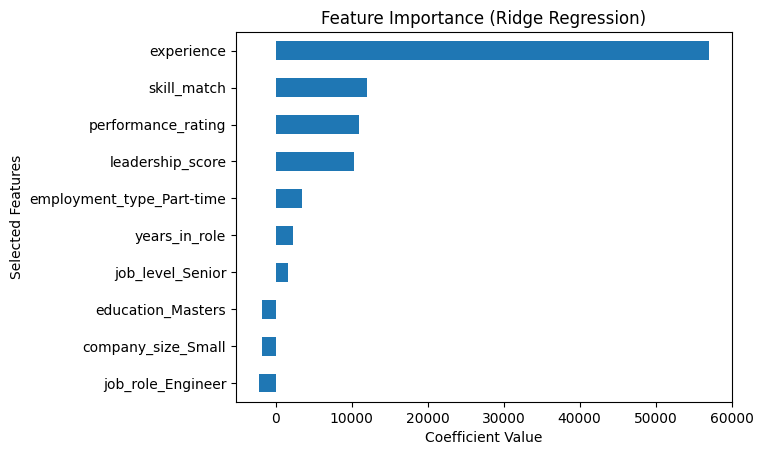

In [21]:
#feature importance
selected_features = X.columns[sfs.get_support()]
importance = pd.Series(ridge.coef_, index=selected_features)

importance.sort_values().plot(kind="barh")
plt.title("Feature Importance (Ridge Regression)")
plt.xlabel("Coefficient Value")
plt.ylabel("Selected Features")
plt.show()

In [22]:
#evaluation
r2_lr = r2_score(y_test, pred_lr)
r2_ridge = r2_score(y_test, pred_ridge)
r2_lasso = r2_score(y_test, pred_lasso)

rmse_lr = np.sqrt(mean_squared_error(y_test, pred_lr))
rmse_ridge = np.sqrt(mean_squared_error(y_test, pred_ridge))
rmse_lasso = np.sqrt(mean_squared_error(y_test, pred_lasso))
#comparison table
results = pd.DataFrame({
    "Model": ["Linear", "Ridge", "Lasso"],
    "R2 Score": [r2_lr, r2_ridge, r2_lasso],
    "RMSE": [rmse_lr, rmse_ridge, rmse_lasso]
})

print(results)
print("Linear Regression Accuracy:", round(r2_lr * 100, 2), "%")
print("Ridge Regression Accuracy:", round(r2_ridge * 100, 2), "%")
print("Lasso Regression Accuracy:", round(r2_lasso * 100, 2), "%")

    Model  R2 Score         RMSE
0  Linear  0.823768  8493.305554
1   Ridge  0.823321  8504.073557
2   Lasso  0.823744  8493.879755
Linear Regression Accuracy: 82.38 %
Ridge Regression Accuracy: 82.33 %
Lasso Regression Accuracy: 82.37 %


In [23]:
#Convert Salary into Categories for classification
df["salary_category"] = pd.cut(
    df["salary"],
    bins=3,
    labels=["Low", "Medium", "High"]
)
print(df[["salary", "salary_category"]].head())

#Classification Dataset
X_class = df.drop(["salary", "salary_category"], axis=1)
y_class = df["salary_category"]

X_class = pd.get_dummies(X_class, drop_first=True)

#Train-Test Split for Classification
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_class,
y_class,test_size=0.2,random_state=42)

#Logistic Regression
c_lf = LogisticRegression(max_iter=1000)
c_lf.fit(X_train_c, y_train_c)

pred_class = c_lf.predict(X_test_c)

#Confusion Matrix + Precision + Recall + F1
cm = confusion_matrix(y_test_c, pred_class)
print("Confusion Matrix:")
print(cm)
precision = precision_score(y_test_c, pred_class, average="weighted")
recall = recall_score(y_test_c, pred_class, average="weighted")
f1 = f1_score(y_test_c, pred_class, average="weighted")
print("Precision Score:", precision)
print("Recall Score:", recall)
print("F1 Score:", f1)
print(classification_report(y_test_c, pred_class))

         salary salary_category
0  57545.519834             Low
1  51024.575364             Low
2  91913.026252          Medium
3  56080.465957             Low
4  99002.186129          Medium
Confusion Matrix:
[[ 42   0  14]
 [  0  70  14]
 [ 11   9 140]]
Precision Score: 0.8404702385691161
Recall Score: 0.84
F1 Score: 0.8396285614007152
              precision    recall  f1-score   support

        High       0.79      0.75      0.77        56
         Low       0.89      0.83      0.86        84
      Medium       0.83      0.88      0.85       160

    accuracy                           0.84       300
   macro avg       0.84      0.82      0.83       300
weighted avg       0.84      0.84      0.84       300



C:\Users\hp\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


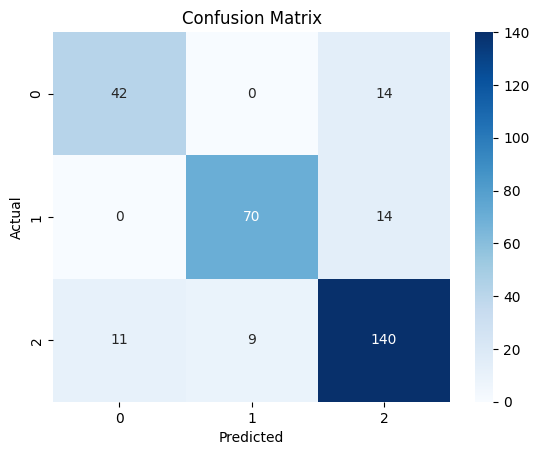

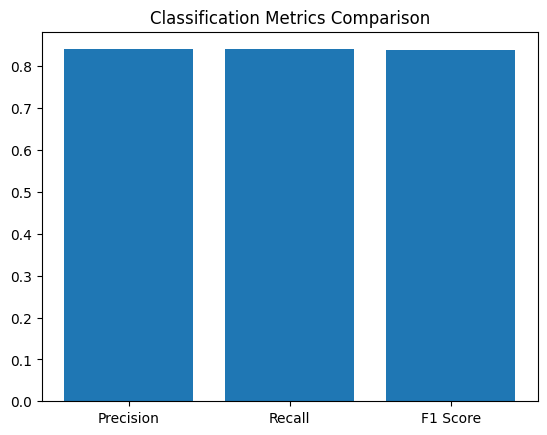

In [24]:
#Confusion Matrix Heatmap
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

scores = {
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1
}

plt.bar(scores.keys(), scores.values())
plt.title("Classification Metrics Comparison")
plt.show()

In [25]:
#best model 
best_model = results.loc[results["R2 Score"].idxmax()]
print("Best Model:")
print(best_model)

Best Model:
Model            Linear
R2 Score       0.823768
RMSE        8493.305554
Name: 0, dtype: object


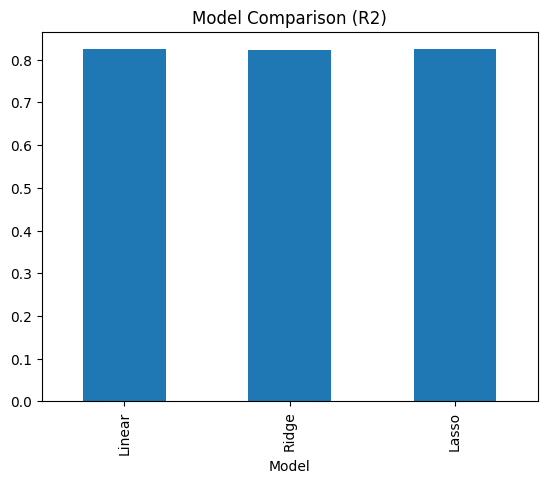

In [26]:
#bar graph of model comparison
results.set_index("Model")["R2 Score"].plot(kind='bar')
plt.title("Model Comparison (R2)")
plt.show()

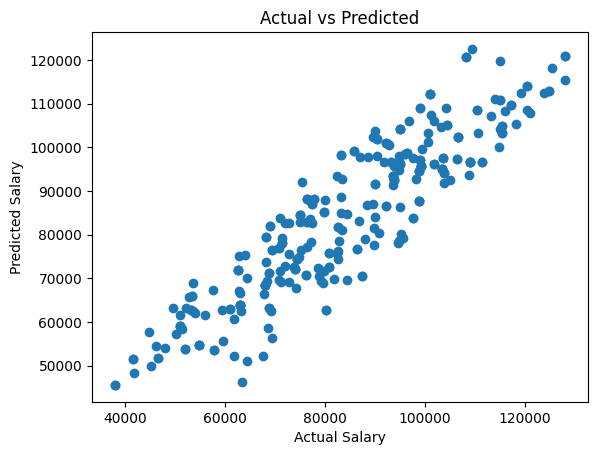

In [27]:
#residual plot
plt.scatter(y_test, pred_lr)
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted")
plt.show()

AS OUR BEST MODEL ACCORDING TO OUR IMPLEMENTAION IS RIDGE REGRESSION 
HENCE WE FIND THE TRAIN,TEST SCORE AND PREDCITION ACCORDING TO IT ONLY
FOR BETTER USE.

In [28]:
#train vs test score
train_score=ridge.score(X_train_sfs, y_train)
test_score= ridge.score(X_test_sfs, y_test)
print("Train Score:", train_score)
print("Test Score:", test_score)
print("Train Score of Ridge Regression:", round(train_score * 100, 2), "%")
print("Test Score of Ridge Regression:", round(test_score * 100, 2), "%")

Train Score: 0.81821247233523
Test Score: 0.823320583442658
Train Score of Ridge Regression: 81.82 %
Test Score of Ridge Regression: 82.33 %


In [29]:
#prediction
prediction = ridge.predict(X_test_sfs[:1])
print("Predicted Salary:", prediction)

Predicted Salary: [62854.00602832]


In [30]:
#new data prediction
print("\nEnter Employee Details\n")
experience = int(input("Enter Experience: "))
performance_rating = int(input("Enter Performance Rating: "))
projects_completed = int(input("Enter Projects Completed: "))
overtime_hours = int(input("Enter Overtime Hours: "))
team_size = int(input("Enter Team Size: "))
leadership_score = float(input("Enter Leadership Score: "))
promotion_count = int(input("Enter Promotion Count: "))
age = int(input("Enter Age: "))
certifications = int(input("Enter Certifications: "))
weekly_hours = int(input("Enter Weekly Work Hours: "))

new_data = pd.DataFrame({
    "experience": [experience],
    "performance_rating": [performance_rating],
    "projects_completed": [projects_completed],
    "overtime_hours": [overtime_hours],
    "team_size": [team_size],
    "leadership_score": [leadership_score],
    "promotion_count": [promotion_count],
    "age": [age],
    "certifications": [certifications],
    "weekly_work_hours": [weekly_hours]
})

# prediction according to best model
predicted_salary = ridge.predict(new_data.values)

print("\nPredicted Salary:", round(predicted_salary[0], 2))


Enter Employee Details



Enter Experience:  5
Enter Performance Rating:  2
Enter Projects Completed:  14
Enter Overtime Hours:  2
Enter Team Size:  8
Enter Leadership Score:  5
Enter Promotion Count:  3
Enter Age:  22
Enter Certifications:  3
Enter Weekly Work Hours:  42



Predicted Salary: 411424.04


Conclusion:
The project successfully predicts employee salary using regression models.
From linear,lasso,ridge regression,Ridge Regression performed best based on R² score and RMSE.
Feature selection for best model and normalization improved model performance.